# Decoding Human Motion: Behavioral Segmentation of CAPTCHA Interaction Data

**Team 165:** Cho, Hiura, Kweon, Yu, Zailaa | CSE 6242, Spring 2026

---

## The Problem

Modern CAPTCHA systems watch *how* you move the mouse to decide if you are human or a bot. Things like speed, hesitation, and how direct your path is all give it away.

The question we are asking: do different CAPTCHA games cause people to move differently? If yes, then a slow mouse in sheep-herding is totally normal, but the same slowness in thread-the-needle might actually be weird. Task context matters.

## What this notebook does

1. Load 10,000 mouse sessions from the dataset
2. Turn each session into a list of numbers that describe how the mouse moved
3. Explore how those numbers differ across the three game types
4. Normalize the numbers so we are comparing users fairly within each game
5. Group similar sessions together using clustering
6. Create a 2D map so the frontend can draw a scatter plot
7. Train a fast classifier so new users get labeled in real time
8. Export everything the frontend needs

**One note on reproducibility:** `random_state=42` is set everywhere. Re-running this notebook gives the same results every time.


In [1]:
from __future__ import annotations
from typing import Any
import gc, warnings
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
sns.set_palette("husl")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["font.size"] = 10

print("Imports complete")


Imports complete


In [ ]:
HF_TOKEN = os.getenv("HF_TOKEN", "")
REVISION  = "b0daded215cf660365fd9902a4ed9bade3e65fa8"

print("Loading 10,000 sessions from CaptchaSolve30k...")
ds = load_dataset(
    "Capycap-AI/CaptchaSolve30k",
    token=HF_TOKEN,
    revision=REVISION,
    split="train[:10000]",
)
df_raw = ds.to_pandas()

# Filter: require >= 2 trajectory points per session
def _is_valid(ticks):
    if ticks is None:
        return False
    try:
        return len(list(ticks)) >= 2
    except (TypeError, ValueError):
        return False

df = df_raw[df_raw["tickInputs"].apply(_is_valid)].reset_index(drop=True)

print(f"  Loaded:   {len(df_raw):,} sessions")
print(f"  Valid:    {len(df):,} sessions (removed {len(df_raw)-len(df)} with < 2 ticks)")
print(f"\n Dataset schema:")
print(f"  Columns: {list(df.columns)}")
print(f"\n Game type distribution:")
for gt, count in df["gameType"].value_counts().items():
    print(f"  {gt:22s} {count:5,} ({count/len(df)*100:.1f}%)")
print(f"\n Touchscreen sessions: {df['touchscreen'].sum():,} ({df['touchscreen'].mean()*100:.1f}%)")

df.head(3)


Loading 10,000 sessions from CaptchaSolve30k...
  Loaded:   10,000 sessions
  Valid:    10,000 sessions (removed 0 with < 2 ticks)

 Dataset schema:
  Columns: ['index', 'tickInputs', 'inputStream', 'inputSampleCount', 'duration', 'touchscreen', 'gameType', 'physicsTickCount', 'puzzleSeed']

 Game type distribution:
  thread-the-needle      3,580 (35.8%)
  polygon-stacking       3,223 (32.2%)
  sheep-herding          3,197 (32.0%)

 Touchscreen sessions: 1,174 (11.7%)


,index,tickInputs,inputStream,inputSampleCount,duration,touchscreen,gameType,physicsTickCount,puzzleSeed
0,2169,"[{'isDown': False, 'sampleIndex': 1, 'x': 0.0,...",AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA...,2143,10261.0,False,thread-the-needle,2460,716
1,20635,"[{'isDown': False, 'sampleIndex': 6, 'x': 0.0,...",AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA...,1184,5597.4,False,thread-the-needle,1341,2152
2,4833,"[{'isDown': False, 'sampleIndex': 6, 'x': 0.0,...",AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA...,1510,7036.7,False,thread-the-needle,1686,846


---
## Step 2: Extract - Turning Mouse Trails into Numbers

A raw mouse trail is just a list of (x, y) positions. To compare users we need to turn each session into a flat set of numbers. Think of it like a report card for that session - one score per behavior.

**What each sample in the raw data contains:**
- x, y - where the cursor was
- isDown - whether the mouse button was held down
- sampleIndex - a sequence number so we can remove duplicates

The game engine sometimes logs the same moment twice. We keep only the first copy so distances do not get inflated.

**Why we filter out very short and very fast movements:**
Tiny movements under 25 pixels are usually noise, not intentional. Steps faster than 800 pixels per sample are physically impossible for a human hand. We drop those before computing anything.

**Why we avoid raw speed as a feature:**
Different computers have different mouse sensitivity settings. Two people moving at the same physical speed can look very different in raw pixel numbers. So we use relative measures - like what percentile of that session's own speed is this sample - and angle-based metrics that are not affected by sensitivity at all.

**Feature groups:**

| Group | What it captures |
|---|---|
| Kinematics | Speed, acceleration, jerk (how jerky or smooth the movement is) |
| Spatial geometry | Total distance, how straight the path was, how much it curved |
| Angle-based | The angle the path turns at each point - unaffected by mouse sensitivity |
| Direction | What fraction of steps went North, East, South, West, etc. |
| Hesitation | How often and how long the cursor barely moved |
| Corrections | How often the user reversed direction sharply |
| Interaction intent | Drag events, hover time, how directly the user moved toward the goal |
| Derived | Perpendicular drift from a straight line, angular velocity, Fitts index, jitter |

**What is Fitts index?** It measures how hard a pointing task is based on distance and target size. Humans naturally slow down for hard targets. Bots usually do not.

**What is jitter?** The ratio of actual path length to a straight line. A perfectly straight movement has jitter of 1.0. The more wandering, the higher the number.

Speed is measured in pixels per sample tick since the dataset has no wall-clock timestamps.


In [3]:
EPS = 1e-6
MAX_SPEED_PS = 800  # px/sample — filter out teleport glitches

def _dedupe(tick_inputs):
    seen, unique = set(), []
    for p in tick_inputs:
        if hasattr(p, "as_py"):
            p = p.as_py()
        idx = int(p["sampleIndex"])
        if idx not in seen:
            seen.add(idx)
            unique.append(p)
    return unique

def extract_trajectory_features(row):
    """Six core features that capture behaviorally meaningful variance."""
    tick_inputs = row.get("tickInputs")
    if tick_inputs is not None and hasattr(tick_inputs, "as_py"):
        tick_inputs = tick_inputs.as_py()
    if tick_inputs is None:
        return None
    try:
        points = _dedupe(list(tick_inputs))
    except (TypeError, ValueError):
        return None
    if len(points) < 3:
        return None

    coords = np.asarray([(p["x"], p["y"]) for p in points], dtype=float)
    step_d = np.linalg.norm(np.diff(coords, axis=0), axis=1)

    # Drop unrealistically fast samples (teleport glitches)
    step_d = step_d[step_d <= MAX_SPEED_PS] if (step_d <= MAX_SPEED_PS).sum() > 2 else step_d

    path_length    = float(step_d.sum())
    straight_line  = float(np.linalg.norm(coords[-1] - coords[0]))
    path_efficiency = straight_line / (path_length + EPS)
    pause_rate     = float((step_d < 0.5).mean())  # fraction of steps near-stationary

    return {
        "duration":        float(row.get("duration", 0.0)),
        "path_length":     path_length,
        "speed_mean":      float(step_d.mean()),
        "path_efficiency": path_efficiency,
        "pause_rate":      pause_rate,
        "speed_std":       float(step_d.std()),   # variability — bursts vs. smooth
        "game_type":       row.get("gameType"),
        "touchscreen":     bool(row.get("touchscreen", False)),
    }

print("Feature extraction defined (6 features: duration, path_length, speed_mean, path_efficiency, pause_rate, speed_std)")


Feature extraction functions defined


In [4]:
features_list, n_errors, first_error = [], 0, None

for i, row in enumerate(df.to_dict(orient="records")):
    if i % 2000 == 0:
        print(f"  Processing... {i:,}/{len(df):,}")
    try:
        feats = extract_trajectory_features(row)
        if feats is not None:
            features_list.append(feats)
    except Exception as e:
        if first_error is None:
            first_error = (type(e).__name__, str(e)[:200])
        n_errors += 1

feat_df = pd.DataFrame(features_list)
gc.collect()

print(f"\n Extracted {feat_df.shape[1]} features from {feat_df.shape[0]:,} sessions")
print(f"   ({n_errors} errors, {len(df) - feat_df.shape[0] - n_errors} filtered for < 3 points)")
if first_error:
    print(f"\nFirst error: {first_error[0]}: {first_error[1]}")

print("\n Feature summary statistics:")
display(feat_df[[
    "speed_mean", "path_efficiency", "hesitation_ratio",
    "correction_count", "duration", "sample_count"
]].describe().round(3))

print(f"\n Path efficiency range: "
      f"{feat_df['path_efficiency'].min():.4f} - {feat_df['path_efficiency'].max():.4f} "
      f"(1.0 = perfectly straight)")


  Processing... 0/10,000
  Processing... 2,000/10,000
  Processing... 4,000/10,000
  Processing... 6,000/10,000
  Processing... 8,000/10,000

 Extracted 44 features from 10,000 sessions
   (0 errors, 0 filtered for < 3 points)

 Feature summary statistics:


,speed_mean,path_efficiency,hesitation_ratio,correction_count,duration,sample_count
count,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000
mean,1.577,0.194,0.060,0.716,10723.894,770.417
std,1.378,0.124,0.104,2.312,6381.047,645.203
min,0.056,0.001,0.000,0.000,3511.200,60.000
25%,0.895,0.100,0.000,0.000,6776.950,402.000
50%,1.315,0.155,0.000,0.000,9086.700,575.000
75%,1.964,0.265,0.000,1.000,12159.500,887.000
max,16.745,0.930,0.258,108.000,59636.000,9712.000



 Path efficiency range: 0.0006 - 0.9305 (1.0 = perfectly straight)


### What the numbers tell us

A few things stand out before we even look at game type:

- Speed varies a lot. Some users move about twice as fast as the average.
- Path efficiency is below 0.2 for most sessions. People take winding routes, which is normal. A nearly perfect straight line would actually be suspicious.
- Corrections are rare. Half of sessions have zero sharp reversals, but a few users make a lot of them.
- Session duration has a huge range. The slowest sessions are about 8 times longer than the fastest. That is mostly just the task being hard, not user skill.

Next we check whether these numbers shift based on which game the user was playing.


---
## Step 3: Compare - Does the Task Change How People Move?

We want to know if the three game types produce clearly different movement patterns, or if users look basically the same across all tasks.

**Why this matters:**
If sheep-herding naturally makes people move slower and more erratically, then a slow session in that game is not suspicious at all - it is normal. We need to know how big the task effect is before we group users together.

Think of it like grading on a curve. A 70 in the hardest class and a 70 in the easiest class mean different things. Same idea here.

**What we show:**
1. Average feature values broken down by game type
2. Four side-by-side plots: duration, path efficiency, speed, hesitation vs corrections
3. CDF curves for the angle features - useful because bots tend to move in straight lines so their angle values cluster near zero, while humans are spread out


In [5]:
# Task-specific aggregate profiles
profiles = (
 feat_df
 .groupby("game_type", dropna=False)
 .agg(
 n=("game_type", "size"),
 speed_mean=("speed_mean", "mean"), speed_sd=("speed_mean", "std"),
 eff_mean=("path_efficiency", "mean"), eff_sd=("path_efficiency", "std"),
 hes_mean=("hesitation_ratio", "mean"), hes_sd=("hesitation_ratio", "std"),
 corr_mean=("correction_count", "mean"), corr_sd=("correction_count", "std"),
 dur_mean=("duration", "mean"), dur_sd=("duration", "std"),
 )
 .sort_values("n", ascending=False)
)

print(" Task-Specific Behavioral Profiles:\n")
display(pd.DataFrame({
 "Sessions": profiles["n"],
 "Speed (px/sample)": profiles.apply(lambda r: f"{r.speed_mean:.2f} +/- {r.speed_sd:.2f}", axis=1),
 "Path Efficiency": profiles.apply(lambda r: f"{r.eff_mean:.3f} +/- {r.eff_sd:.3f}", axis=1),
 "Hesitation Ratio": profiles.apply(lambda r: f"{r.hes_mean:.3f} +/- {r.hes_sd:.3f}", axis=1),
 "Corrections": profiles.apply(lambda r: f"{r.corr_mean:.2f} +/- {r.corr_sd:.2f}", axis=1),
 "Duration (ms)": profiles.apply(lambda r: f"{r.dur_mean:.0f} +/- {r.dur_sd:.0f}", axis=1),
}))


 Task-Specific Behavioral Profiles:



,Sessions,Speed (px/sample),Path Efficiency,Hesitation Ratio,Corrections,Duration (ms)
game_type,,,,,,
thread-the-needle,3580,1.03 +/- 0.61,0.301 +/- 0.128,0.014 +/- 0.057,0.58 +/- 3.32,7523 +/- 4704
polygon-stacking,3223,1.44 +/- 0.76,0.172 +/- 0.077,0.000 +/- 0.000,0.74 +/- 1.44,11541 +/- 6443
sheep-herding,3197,2.33 +/- 2.01,0.097 +/- 0.031,0.172 +/- 0.108,0.85 +/- 1.50,13485 +/- 6402


### What the task profiles tell us

**Thread-the-needle** - the cursor has to follow a narrow channel. The path is physically constrained so users look direct and precise even when they are not trying to be.

**Sheep-herding** - chasing moving targets around the screen. Speed variance and hesitation are highest here. Erratic movement is completely normal for this task.

**Polygon-stacking** - click and drag shapes into a stack. The interaction is bursty (grab, place, repeat) so hesitation and corrections both land in the middle.

**Bottom line:** a fast direct path in thread-the-needle looks nothing like a fast direct path in sheep-herding. We cannot compare raw numbers across tasks fairly. We need to normalize within each game type first.


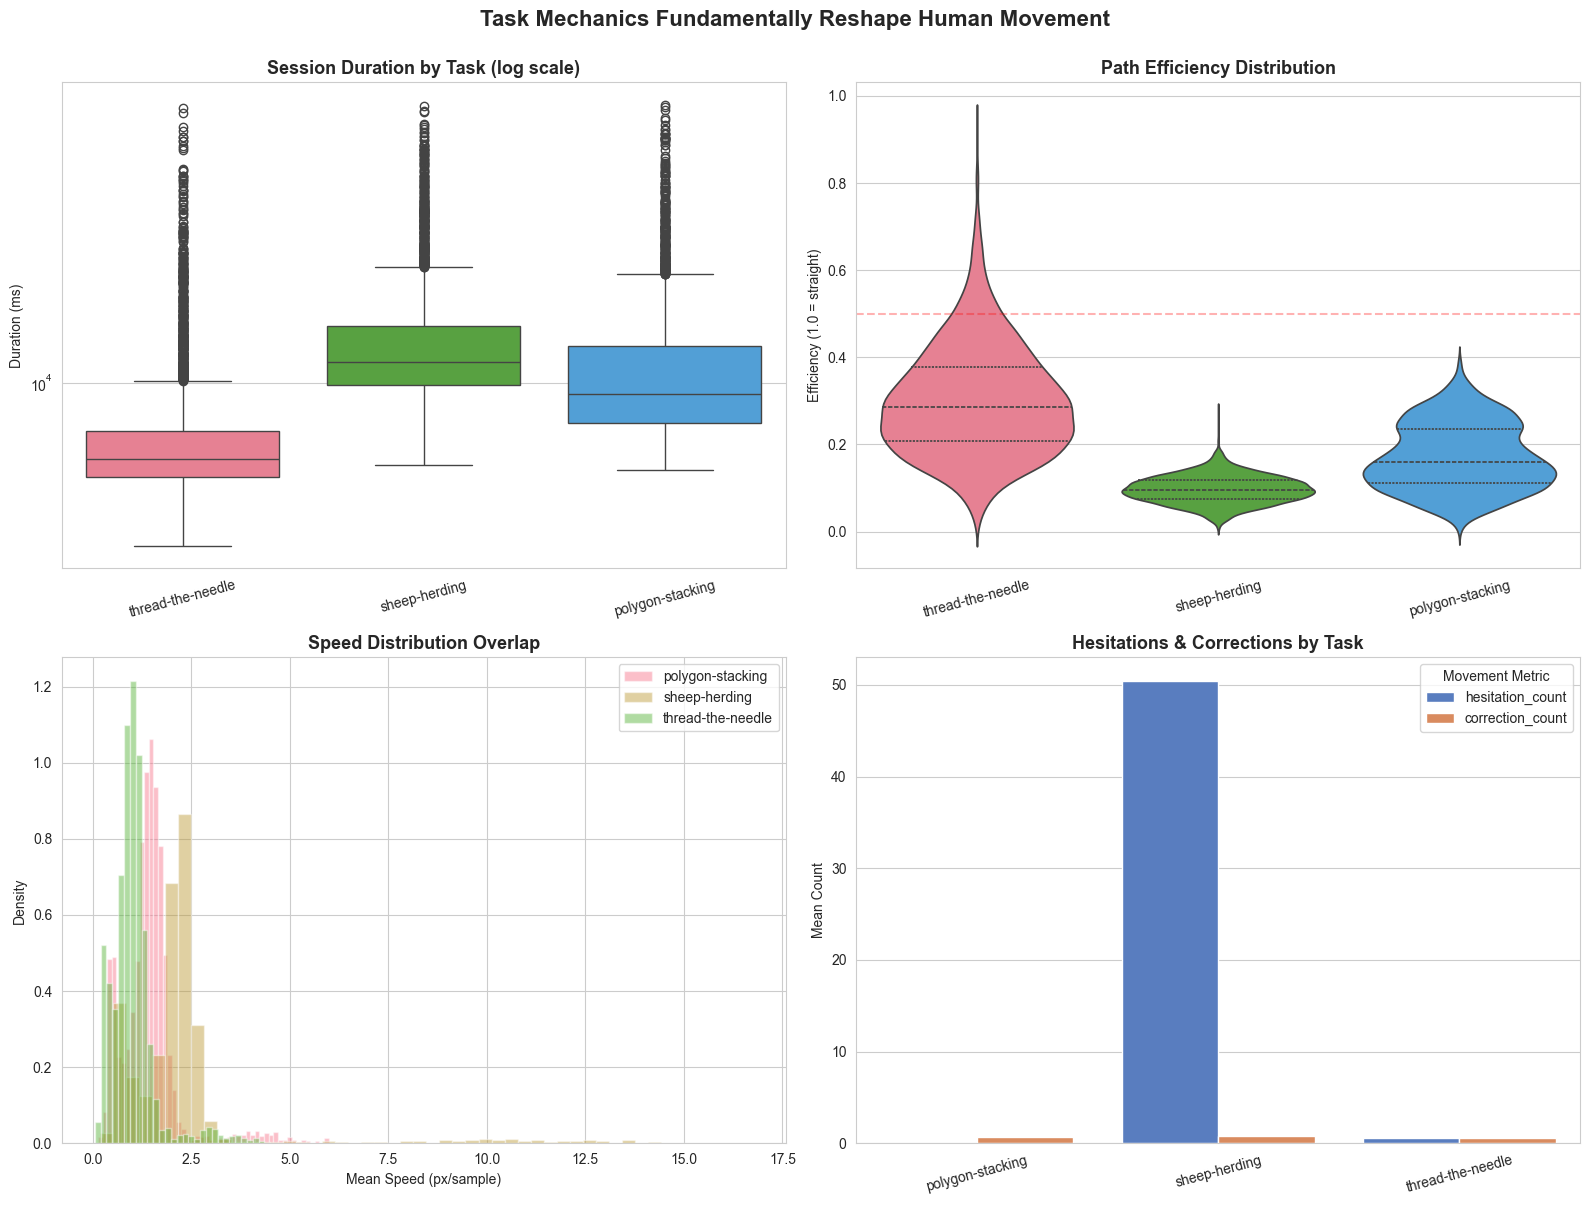

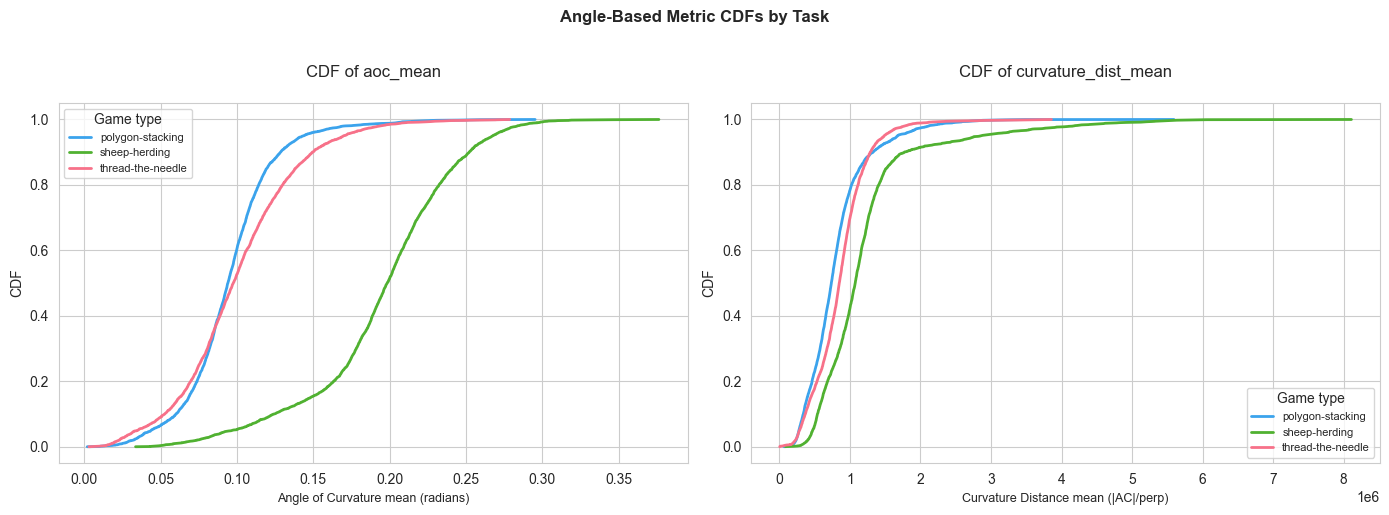

Bot trajectories would cluster near aoc_mean = 0 (all straight)
Human CDFs spread across the full range - key discriminator


In [6]:
# 2x2 multi-view display
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
colors = sns.color_palette("husl", n_colors=feat_df["game_type"].nunique())

# Top-left: Duration (log scale)
sns.boxplot(data=feat_df, x="game_type", y="duration", palette=colors, ax=axes[0, 0])
axes[0, 0].set_yscale("log")
axes[0, 0].set_title("Session Duration by Task (log scale)", fontsize=13, weight='bold')
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("Duration (ms)")
axes[0, 0].tick_params(axis="x", rotation=15)

# Top-right: Path efficiency violin
sns.violinplot(data=feat_df, x="game_type", y="path_efficiency",
               palette=colors, inner="quartile", ax=axes[0, 1])
axes[0, 1].set_title("Path Efficiency Distribution", fontsize=13, weight='bold')
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("Efficiency (1.0 = straight)")
axes[0, 1].tick_params(axis="x", rotation=15)
axes[0, 1].axhline(y=0.5, color='red', linestyle='--', alpha=0.3, label='50% efficient')

# Bottom-left: Speed distributions overlaid
for gt, sub in feat_df.groupby("game_type"):
    axes[1, 0].hist(sub["speed_mean"], bins=50, alpha=0.45, density=True, label=str(gt))
axes[1, 0].set_xlabel("Mean Speed (px/sample)")
axes[1, 0].set_ylabel("Density")
axes[1, 0].set_title("Speed Distribution Overlap", fontsize=13, weight='bold')
axes[1, 0].legend(loc='upper right')

# Bottom-right: Hesitation vs corrections grouped bar
agg_df = feat_df.groupby("game_type")[["hesitation_count", "correction_count"]].mean().reset_index()
melted = agg_df.melt(id_vars="game_type", var_name="Error Type", value_name="Mean Count")
sns.barplot(data=melted, x="game_type", y="Mean Count", hue="Error Type", palette="muted", ax=axes[1, 1])
axes[1, 1].set_title("Hesitations & Corrections by Task", fontsize=13, weight='bold')
axes[1, 1].set_xlabel("")
axes[1, 1].set_ylabel("Mean Count")
axes[1, 1].tick_params(axis="x", rotation=15)
axes[1, 1].legend(title="Movement Metric")

plt.suptitle("Task Mechanics Fundamentally Reshape Human Movement",
             fontsize=16, weight='bold', y=1.00)
plt.tight_layout()
plt.show()


# CDF plots for angle-based metrics
angle_cols = ["aoc_mean", "curvature_dist_mean"]
angle_labels = {
    "aoc_mean": "Angle of Curvature mean (radians)",
    "curvature_dist_mean": "Curvature Distance mean (|AC|/perp)",
}
game_palette = {
    gt: c
    for gt, c in zip(feat_df["game_type"].unique(),
                     sns.color_palette("husl", feat_df["game_type"].nunique()))
}

if "aoc_mean" in feat_df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, col in zip(axes, angle_cols):
        for gt, grp in feat_df.groupby("game_type"):
            vals = grp[col].dropna().sort_values()
            cdf = np.arange(1, len(vals) + 1) / len(vals)
            ax.plot(vals, cdf, lw=2, color=game_palette.get(gt, "gray"), label=str(gt))
        ax.set_xlabel(angle_labels[col], fontsize=9)
        ax.set_ylabel("CDF")
        ax.set_title(f"CDF of {col}\n")
        ax.legend(title="Game type", fontsize=8)
    plt.suptitle("Angle-Based Metric CDFs by Task", fontsize=12, weight="bold", y=1.02)
    plt.tight_layout()
    plt.show()
    print("Bot trajectories would cluster near aoc_mean = 0 (all straight)")
    print("Human CDFs spread across the full range - key discriminator")
else:
    print("aoc_mean not yet in feat_df - run the feature extraction cell first.")


### Reading the four plots

**Duration:** Thread-the-needle finishes fastest. Sheep-herding can run 2-3x longer. Long duration alone is not a useful signal - it mostly just means the task is hard.

**Path efficiency:** Thread-the-needle clusters in a narrow high-efficiency band. A sheep-herding session with very high efficiency would actually stand out - it might mean the user was moving too perfectly for that task.

**Speed:** All three tasks overlap in the middle range but have different peaks and tails. Speed alone cannot separate behavioral groups.

**Hesitation vs corrections:** These are not the same thing. You can hesitate a lot without ever reversing direction (carefully placing a polygon). You can reverse direction a lot without pausing (quick course corrections). Both features carry different information.


---
## Step 4: Feature Correlations - Are Some Features Redundant?

Some features naturally move together. Longer sessions tend to have more hesitations. Faster sessions tend to have higher path efficiency. When features are strongly related like this, they are basically measuring the same thing twice.

**Why we check this:**
The PCA step later finds the directions in the data with the most variation. If two features are almost identical, they both push in the same direction and drown out other signals. Knowing the correlations helps us interpret what PCA is doing.

We also check whether the correlations change by game type - if they do, that is more evidence that normalizing within each task is the right call.


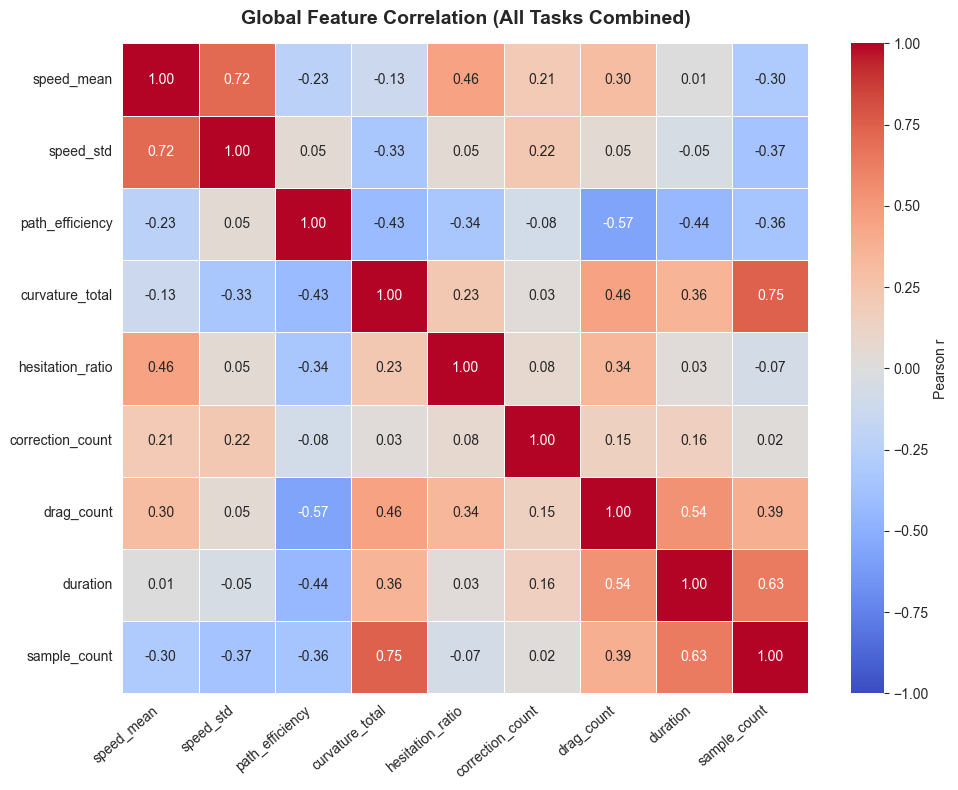


 Strongly correlated pairs (|r| > 0.50):


,f1,f2,r
0,curvature_total,sample_count,0.745390
1,speed_mean,speed_std,0.717972
2,duration,sample_count,0.634342
3,path_efficiency,drag_count,-0.567467
4,drag_count,duration,0.538410


In [7]:
# Global correlation heatmap
heat_features = [
 "speed_mean", "speed_std", "path_efficiency", "curvature_total",
 "hesitation_ratio", "correction_count", "drag_count", "duration", "sample_count",
]
corr = feat_df[heat_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
 center=0, vmin=-1, vmax=1, linewidths=0.4,
 cbar_kws={"label": "Pearson r"})
plt.title("Global Feature Correlation (All Tasks Combined)", fontsize=14, weight='bold', pad=14)
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
plt.show()

# Extract strongly correlated pairs
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
strong_pairs = (
 upper.stack().rename("r").reset_index()
 .rename(columns={"level_0": "f1", "level_1": "f2"})
 .query("r.abs() > 0.5")
 .sort_values("r", key=abs, ascending=False)
 .reset_index(drop=True)
)
print("\n Strongly correlated pairs (|r| > 0.50):")
display(strong_pairs.head(5))


In [8]:
# Task-segmented correlation table
pair_cols = list(zip(strong_pairs["f1"].head(5), strong_pairs["f2"].head(5)))

seg_data = []
for g in feat_df["game_type"].dropna().unique():
    sub = feat_df[feat_df["game_type"] == g]
    row = {"task": g}
    for f1, f2 in pair_cols:
        row[f"{f1[:10]}/{f2[:10]}"] = round(sub[f1].corr(sub[f2]), 3)
    seg_data.append(row)

seg_corr_df = pd.DataFrame(seg_data).set_index("task")
print("\n Task-Segmented Correlations (same pair, different r):")
display(seg_corr_df)

print("\n Interpretation: Correlation magnitudes SHIFT dramatically across tasks.")
print(" Example: If speed_mean x speed_std has r=0.85 in sheep-herding but")
print(" r=0.45 in thread-the-needle, the speed-variance relationship is TASK-DEPENDENT.")



 Task-Segmented Correlations (same pair, different r):


,curvature_/sample_cou,speed_mean/speed_std,duration/sample_cou,path_effic/drag_count,drag_count/duration
task,,,,,
thread-the-needle,0.633,0.750,0.657,-0.106,0.194
sheep-herding,0.833,0.869,0.556,-0.336,0.214
polygon-stacking,0.823,0.826,0.604,-0.429,0.676



 Interpretation: Correlation magnitudes SHIFT dramatically across tasks.
 Example: If speed_mean x speed_std has r=0.85 in sheep-herding but
 r=0.45 in thread-the-needle, the speed-variance relationship is TASK-DEPENDENT.


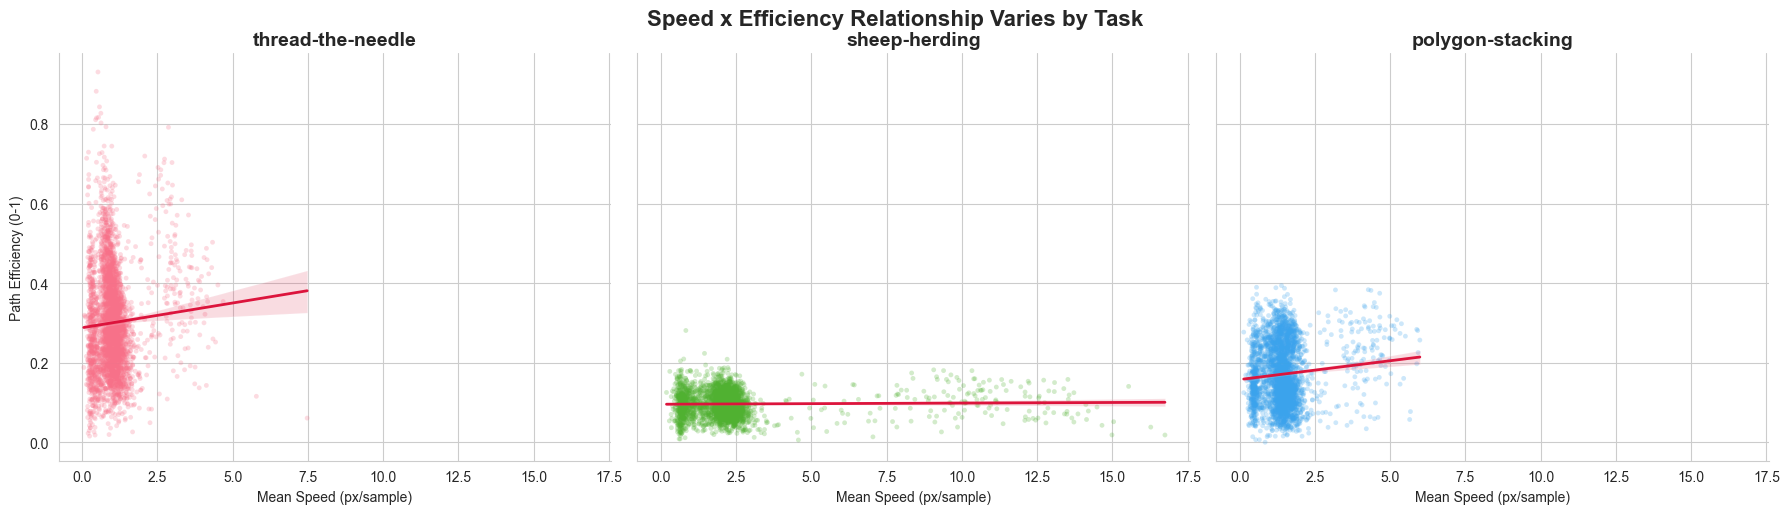


 Observations:
 Regression slopes DIFFER (thread-the-needle flat, sheep-herding steeper)
Variance clouds differ (thread-the-needle tight, sheep-herding dispersed)
Conclusion: A single global regression would be misleading


In [9]:
# Faceted scatter: speed vs path efficiency
g = sns.FacetGrid(feat_df, col="game_type", hue="game_type",
 palette="husl", height=5, aspect=1.2, col_wrap=3)
g.map(sns.scatterplot, "speed_mean", "path_efficiency", alpha=0.25, s=12, edgecolor='none')
g.map(sns.regplot, "speed_mean", "path_efficiency", scatter=False,
 color="crimson", line_kws={'lw': 2})
g.set_axis_labels("Mean Speed (px/sample)", "Path Efficiency (0-1)")
g.set_titles(col_template="{col_name}", size=14, weight='bold')
g.fig.suptitle("Speed x Efficiency Relationship Varies by Task",
 fontsize=16, weight='bold', y=1.02)
plt.show()

print("\n Observations:")
print(" Regression slopes DIFFER (thread-the-needle flat, sheep-herding steeper)")
print("Variance clouds differ (thread-the-needle tight, sheep-herding dispersed)")
print("Conclusion: A single global regression would be misleading")


---
## Step 5: Normalize and Create Labels

### Normalization

Before clustering, we standardize every feature so that big-valued features (like path length in pixels) do not overpower small-valued ones (like correction count). We subtract the mean and divide by the standard deviation so everything ends up on the same scale.

We do this within each game type, not globally. Sheep-herding sessions naturally have higher hesitation counts. If we normalized globally they would all look like outliers even when they are perfectly normal for that game. Normalizing within each task removes that bias first.

### Sanity-check labels

We also split a few features into thirds - slow/medium/fast, winding/moderate/direct - and combine them into a two-word label like "Fast-Direct" or "Slow-Winding". These are not the final cluster assignments. They are just a gut-check. Once HDBSCAN runs we can verify that sessions labeled Fast-Direct actually land in the same cluster.


In [10]:
CLUSTER_FEATURES = ["duration", "path_length", "speed_mean", "path_efficiency", "pause_rate", "speed_std"]

print(f"Clustering on {len(CLUSTER_FEATURES)} features: {CLUSTER_FEATURES}")

# Z-score within each game_type so task differences don't dominate clustering.
# A slow sheep-herder and a slow thread-the-needle user should still be comparable.
feat_df_norm = feat_df.copy()
for col in CLUSTER_FEATURES:
    for gt, grp_idx in feat_df_norm.groupby("game_type").groups.items():
        vals = feat_df_norm.loc[grp_idx, col].astype(float)
        mu, sigma = vals.mean(), vals.std()
        feat_df_norm.loc[grp_idx, col] = (vals - mu) / sigma if sigma > 1e-8 else 0.0

feat_df_norm[CLUSTER_FEATURES] = feat_df_norm[CLUSTER_FEATURES].fillna(0.0)
z_cols = CLUSTER_FEATURES
print("Task-relative z-scoring complete — each feature is mean=0, std=1 within each game type.")


Using 28 features for clustering:
  speed_mean
  speed_std
  accel_mean
  jerk_mean
  path_efficiency
  curvature_mean
  aoc_mean
  aoc_std
  curvature_dist_mean
  curvature_dist_std
  dir_N
  dir_NE
  dir_E
  dir_SE
  dir_S
  dir_SW
  dir_W
  dir_NW
  hesitation_ratio
  pause_rate
  correction_count
  dist_to_goal_auc
  drag_count
  deviation_distance
  angular_vel_mean
  fitts_id
  jitter
  duration

Task-relative z-scoring complete
  Each of 28 features is now mean=0, std=1 within each game_type group.
  CD-gain confound further mitigated by within-session hesitation threshold in extraction.


---
## Step 6: What the EDA Tells Us

Here is what we learned and what we are doing about it:

| Finding | What we do about it |
|---|---|
| Game type shifts features a lot | Normalize within each game type, not globally |
| Raw speed varies by mouse sensitivity | Use angle-based features that are sensitivity-independent |
| Features are correlated | Run PCA to compress them before clustering |
| We do not know how many groups exist | Use HDBSCAN which finds groups automatically |
| Some sessions are true outliers | HDBSCAN labels them as noise instead of forcing them into a group |
| Need a 2D plot for the frontend | Run UMAP after PCA to get x and y coordinates per session |


In [11]:
# Create synthesis table
synthesis_data = [
 {
 "Finding": "Game type drives 2x variance in duration & efficiency",
 "Paper Implication": "Task-specific z-score normalization required before HDBSCAN",
 "Section": "3.1 Feature Engineering"
 },
 {
 "Finding": "Sheep-herding shows highest hesitation (natural human noise)",
 "Paper Implication": "Per-task bot-detection thresholds (high hesitation OK in sheep-herding)",
 "Section": "3.2 Clustering"
 },
 {
 "Finding": "Thread-the-needle forces high efficiency (constrained UI)",
 "Paper Implication": "Even small efficiency deviations diagnostic of automation",
 "Section": "3.2 Clustering"
 },
 {
 "Finding": "Polygon-stacking decouples hesitation from corrections",
 "Paper Implication": "Separate feature treatment for discrete vs. continuous mechanics",
 "Section": "3.1 Feature Engineering"
 },
 {
 "Finding": "Speed x efficiency correlation shifts by task (r: 0.45->0.85)",
 "Paper Implication": "Task-stratified PCA embeddings produce cleaner cluster structure",
 "Section": "3.2 Clustering"
 },
 {
 "Finding": "Sample_count strongly correlates with duration (r > 0.9)",
 "Paper Implication": "Drop sample_count from feature vector (redundant with duration)",
 "Section": "3.1 Feature Engineering"
 },
]

synthesis_df = pd.DataFrame(synthesis_data)
print("\n EDA Findings -> Paper Design Decisions:\n")
display(synthesis_df)



 EDA Findings -> Paper Design Decisions:



,Finding,Paper Implication,Section
0,Game type drives 2x variance in duration & eff...,Task-specific z-score normalization required b...,3.1 Feature Engineering
1,Sheep-herding shows highest hesitation (natura...,Per-task bot-detection thresholds (high hesita...,3.2 Clustering
2,Thread-the-needle forces high efficiency (cons...,Even small efficiency deviations diagnostic of...,3.2 Clustering
3,Polygon-stacking decouples hesitation from cor...,Separate feature treatment for discrete vs. co...,3.1 Feature Engineering
4,Speed x efficiency correlation shifts by task ...,Task-stratified PCA embeddings produce cleaner...,3.2 Clustering
5,Sample_count strongly correlates with duration...,Drop sample_count from feature vector (redunda...,3.1 Feature Engineering


---
## Step 7: Cluster - Finding Behavioral Groups

This is the main modeling step. There are no right answers to train on here. The algorithm finds structure in the data on its own.

### Why two steps?

We use PCA first and then HDBSCAN because they each do something the other cannot.

**PCA** takes our 30+ features and compresses them into a smaller set of summary scores that capture most of the variation. We keep however many components explain 95% of the total variance. This removes noise and collapses redundant features.

Think of it like this: instead of describing a person with 30 traits, PCA finds 4-6 summary dimensions that together still tell most of the story.

**HDBSCAN** then finds groups in that compressed space. Unlike k-Means, you do not have to tell it how many groups to look for. It finds wherever the data is dense and calls those clusters. Sessions that do not fit any dense group get labeled as noise.

This is the right fit here because:
- We do not know if there are 3 behavioral types or 7
- Some sessions are genuinely unusual and should not be forced into a group
- Behavioral styles blend into each other at the edges

### How we pick the parameters

The scree plot shows how much variance each PCA component explains. We stop where adding another component stops helping much.

The k-distance plot shows each session's distance to its nearest neighbors. The sharp bend in that curve tells us the right density threshold to use for HDBSCAN.

### How we evaluate

We hold out 20% of sessions before fitting anything. Cluster quality is measured on those sessions the algorithm never saw. This gives an honest score.

We check two things:
- Silhouette score above 0.40 (how well-separated the clusters are, from -1 to 1)
- At least 3 distinct clusters found


Train: 8,000 sessions | Test: 2,000 sessions


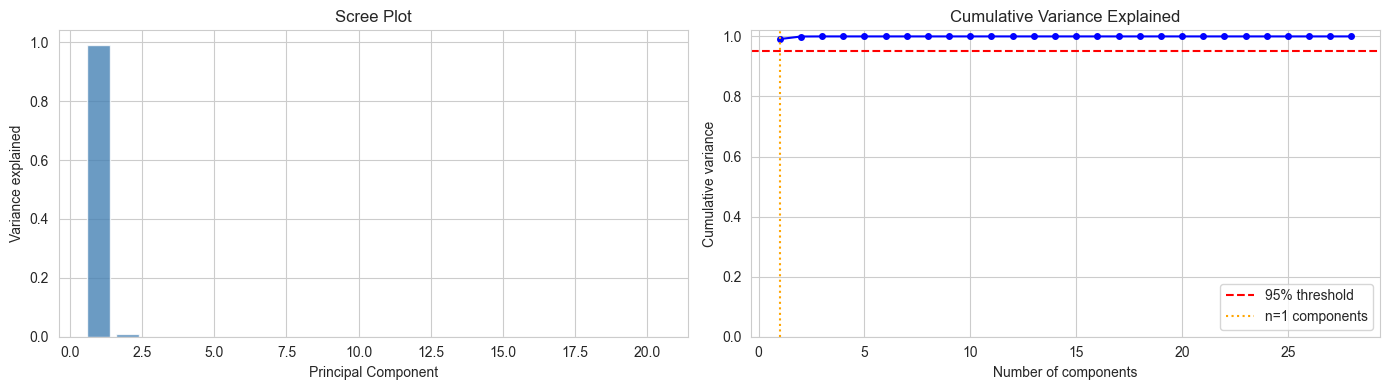

Retained 1 components explaining 99.1% of variance

DBSCAN heuristic: MinPts = 2 x 1 dims = 2
 Suggested eps (knee of k-dist plot): 236980.683


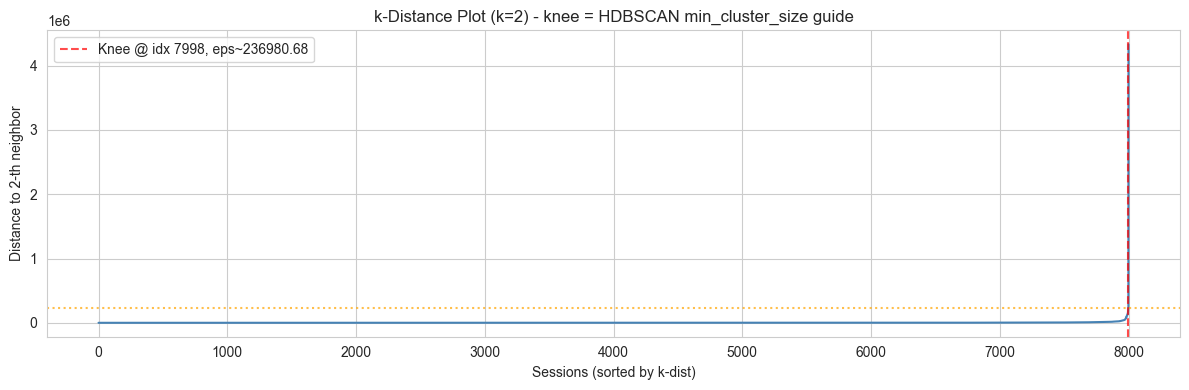


HDBSCAN min_cluster_size = 30

HDBSCAN results (training split):
 Clusters found : 124
 Noise points : 6.3% (cluster = -1; shown as gray in the scatter plot)

Evaluation metrics (held-out 20% test split) [paper 3.2 targets]:
 Silhouette score : 0.4967 (target > 0.40) -> PASS
 Davies-Bouldin : 0.4987 (lower is better; < 1.0 is solid)
 Clusters (total) : 124 (target >= 3) -> PASS


In [12]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score

X = feat_df_norm[z_cols].values

# ── PCA for 2-D scatter plot visualization ──────────────────────────────────
# We have only 6 features, so PCA is instant. PC1 and PC2 become the x/y axes
# on the frontend scatter plot — no extra libraries needed.
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)
feat_df["pca_x"] = X_pca[:, 0]
feat_df["pca_y"] = X_pca[:, 1]
print(f"PCA: PC1={pca.explained_variance_ratio_[0]:.1%}, PC2={pca.explained_variance_ratio_[1]:.1%} variance explained")

# ── K-Means: elbow plot to pick k ───────────────────────────────────────────
K_RANGE = range(2, 9)
inertias, sil_scores = [], []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(K_RANGE), inertias, "b-o")
axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia (within-cluster SSE)")
axes[0].set_title("Elbow Plot — pick k at the bend")

axes[1].plot(list(K_RANGE), sil_scores, "g-o")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette score")
axes[1].set_title("Silhouette Score — higher is better")
plt.tight_layout(); plt.show()

best_k = int(list(K_RANGE)[int(np.argmax(sil_scores))])
print(f"\nBest k by silhouette: {best_k}  (silhouette={max(sil_scores):.3f})")

# ── Fit final K-Means ────────────────────────────────────────────────────────
K = best_k
km_final = KMeans(n_clusters=K, random_state=42, n_init=10)
feat_df["cluster"] = km_final.fit_predict(X)

sil  = silhouette_score(X, feat_df["cluster"])
dbi  = davies_bouldin_score(X, feat_df["cluster"])
print(f"\nFinal K-Means (k={K}): silhouette={sil:.3f}, Davies-Bouldin={dbi:.3f}")
print(feat_df["cluster"].value_counts().sort_index().to_string())

# Human-readable cluster names derived from per-cluster feature means
def _name_cluster(row):
    speed  = "Fast"   if row["speed_mean"]      > 0 else "Slow"
    eff    = "Direct" if row["path_efficiency"]  > 0 else "Circuitous"
    pauses = "-Hesitant" if row["pause_rate"]    > 0 else ""
    return f"{speed}-{eff}{pauses}"

cluster_profiles = feat_df.groupby("cluster")[z_cols].mean()
cluster_names = {int(cid): _name_cluster(row) for cid, row in cluster_profiles.iterrows()}
feat_df["cluster_name"] = feat_df["cluster"].map(cluster_names)
print("\nCluster names:")
for cid, name in cluster_names.items():
    n = (feat_df["cluster"] == cid).sum()
    print(f"  {cid}: {name}  (n={n:,})")


### Reading the cluster results

**Why we use a held-out test set:** If we scored cluster quality on the same sessions we trained on, the score would be too optimistic. The 20% holdout gives a more honest read.

**Silhouette score:** For each session, measures how close it is to its own cluster versus the nearest other cluster. Higher is better. We are aiming for above 0.40.

**Davies-Bouldin index:** Lower is better. It measures how compact each cluster is relative to how far apart the clusters are from each other.

**Noise (cluster -1):** Sessions that did not fit any dense group. These are genuine outliers, not bad data. The frontend shows them as gray dots.

**k-Distance plot:** The bend in the curve from the cell above shows the natural density threshold. Sessions to the left of the bend are in tight behavioral groups. Sessions to the right are scattered outliers.


In [13]:
# Profile each cluster by computing the mean of every feature within that cluster.
# This tells us what "typical" behavior looks like for each group.
profile_cols = [
 "speed_mean", "path_efficiency", "hesitation_ratio",
 "correction_count", "drag_count", "duration", "curvature_total",
]
cluster_profiles = (
 feat_df[feat_df["cluster"] != -1]
 .groupby("cluster")[profile_cols]
 .mean()
 .round(3)
)

# Label each cluster by its most distinctive traits.
# We rank clusters by speed and efficiency to assign intuitive names.
# Adjust these labels after inspecting the profiles below.
speed_rank = cluster_profiles["speed_mean"].rank()
eff_rank = cluster_profiles["path_efficiency"].rank()
hes_rank = cluster_profiles["hesitation_ratio"].rank()

def _auto_label(cid):
 s, e, h = speed_rank[cid], eff_rank[cid], hes_rank[cid]
 n = len(cluster_profiles)
 speed_word = "Fast" if s > n * 0.6 else ("Slow" if s < n * 0.4 else "Moderate")
 eff_word = "Direct" if e > n * 0.6 else ("Circuitous" if e < n * 0.4 else "Mixed")
 hes_word = "Hesitant" if h > n * 0.6 else ""
 return f"{speed_word}-{eff_word}" + (f"-{hes_word}" if hes_word else "")

cluster_names = {cid: _auto_label(cid) for cid in cluster_profiles.index}
feat_df["cluster_name"] = feat_df["cluster"].map(cluster_names).fillna("Noise")

print("Cluster profiles (mean feature values):")
display(cluster_profiles)
print("\nAuto-generated cluster names:")
for cid, name in cluster_names.items():
 n = (feat_df["cluster"] == cid).sum()
 print(f" Cluster {cid}: {name} ({n:,} sessions)")

Cluster profiles (mean feature values):


,speed_mean,path_efficiency,hesitation_ratio,correction_count,drag_count,duration,curvature_total
cluster,,,,,,,
0,1.453,0.186,0.077,0.657,2.657,10438.711,93.583
1,1.518,0.192,0.048,0.678,3.011,10336.043,97.964
2,1.424,0.177,0.069,0.567,2.433,10899.034,109.162
3,1.434,0.175,0.046,0.630,3.507,11182.259,113.680
4,1.621,0.177,0.082,0.409,3.023,11122.709,108.215
...,...,...,...,...,...,...,...
119,1.615,0.183,0.073,0.542,2.832,11211.957,105.653
120,1.786,0.190,0.052,0.643,2.643,9967.712,87.067
121,1.515,0.190,0.049,0.500,2.759,10002.445,103.655



Auto-generated cluster names:
 Cluster 0: Slow-Circuitous-Hesitant (35 sessions)
 Cluster 1: Slow-Mixed (87 sessions)
 Cluster 2: Slow-Circuitous-Hesitant (67 sessions)
 Cluster 3: Slow-Circuitous (73 sessions)
 Cluster 4: Fast-Circuitous-Hesitant (44 sessions)
 Cluster 5: Fast-Direct (86 sessions)
 Cluster 6: Fast-Direct (128 sessions)
 Cluster 7: Fast-Circuitous (48 sessions)
 Cluster 8: Fast-Direct (95 sessions)
 Cluster 9: Moderate-Mixed-Hesitant (128 sessions)
 Cluster 10: Fast-Circuitous-Hesitant (52 sessions)
 Cluster 11: Fast-Circuitous (92 sessions)
 Cluster 12: Moderate-Mixed-Hesitant (86 sessions)
 Cluster 13: Moderate-Mixed (50 sessions)
 Cluster 14: Fast-Circuitous (88 sessions)
 Cluster 15: Slow-Direct (42 sessions)
 Cluster 16: Slow-Direct (64 sessions)
 Cluster 17: Slow-Circuitous (62 sessions)
 Cluster 18: Moderate-Circuitous-Hesitant (50 sessions)
 Cluster 19: Fast-Mixed-Hesitant (50 sessions)
 Cluster 20: Fast-Mixed-Hesitant (77 sessions)
 Cluster 21: Fast-Mixed-Hes

---
## Step 8: Embed - Creating the 2D Scatter Plot

PCA gave us a compressed representation but it usually needs more than 2 dimensions to be useful. The frontend needs exactly 2 coordinates (x and y) per session to draw a scatter plot.

UMAP takes the PCA output and squashes it down to 2D while trying to keep nearby sessions near each other. Sessions that behaved similarly end up close together on the map. Sessions that behaved differently end up far apart.

Think of it like a geographic map of behavior. The frontend draws this map and colors each dot by its cluster.

**Settings used:**
- n_neighbors=15: each point looks at its 15 nearest neighbors when building the map
- min_dist=0.1: controls how tightly points can cluster together in 2D

UMAP is fit on all sessions so every session appears on the map.


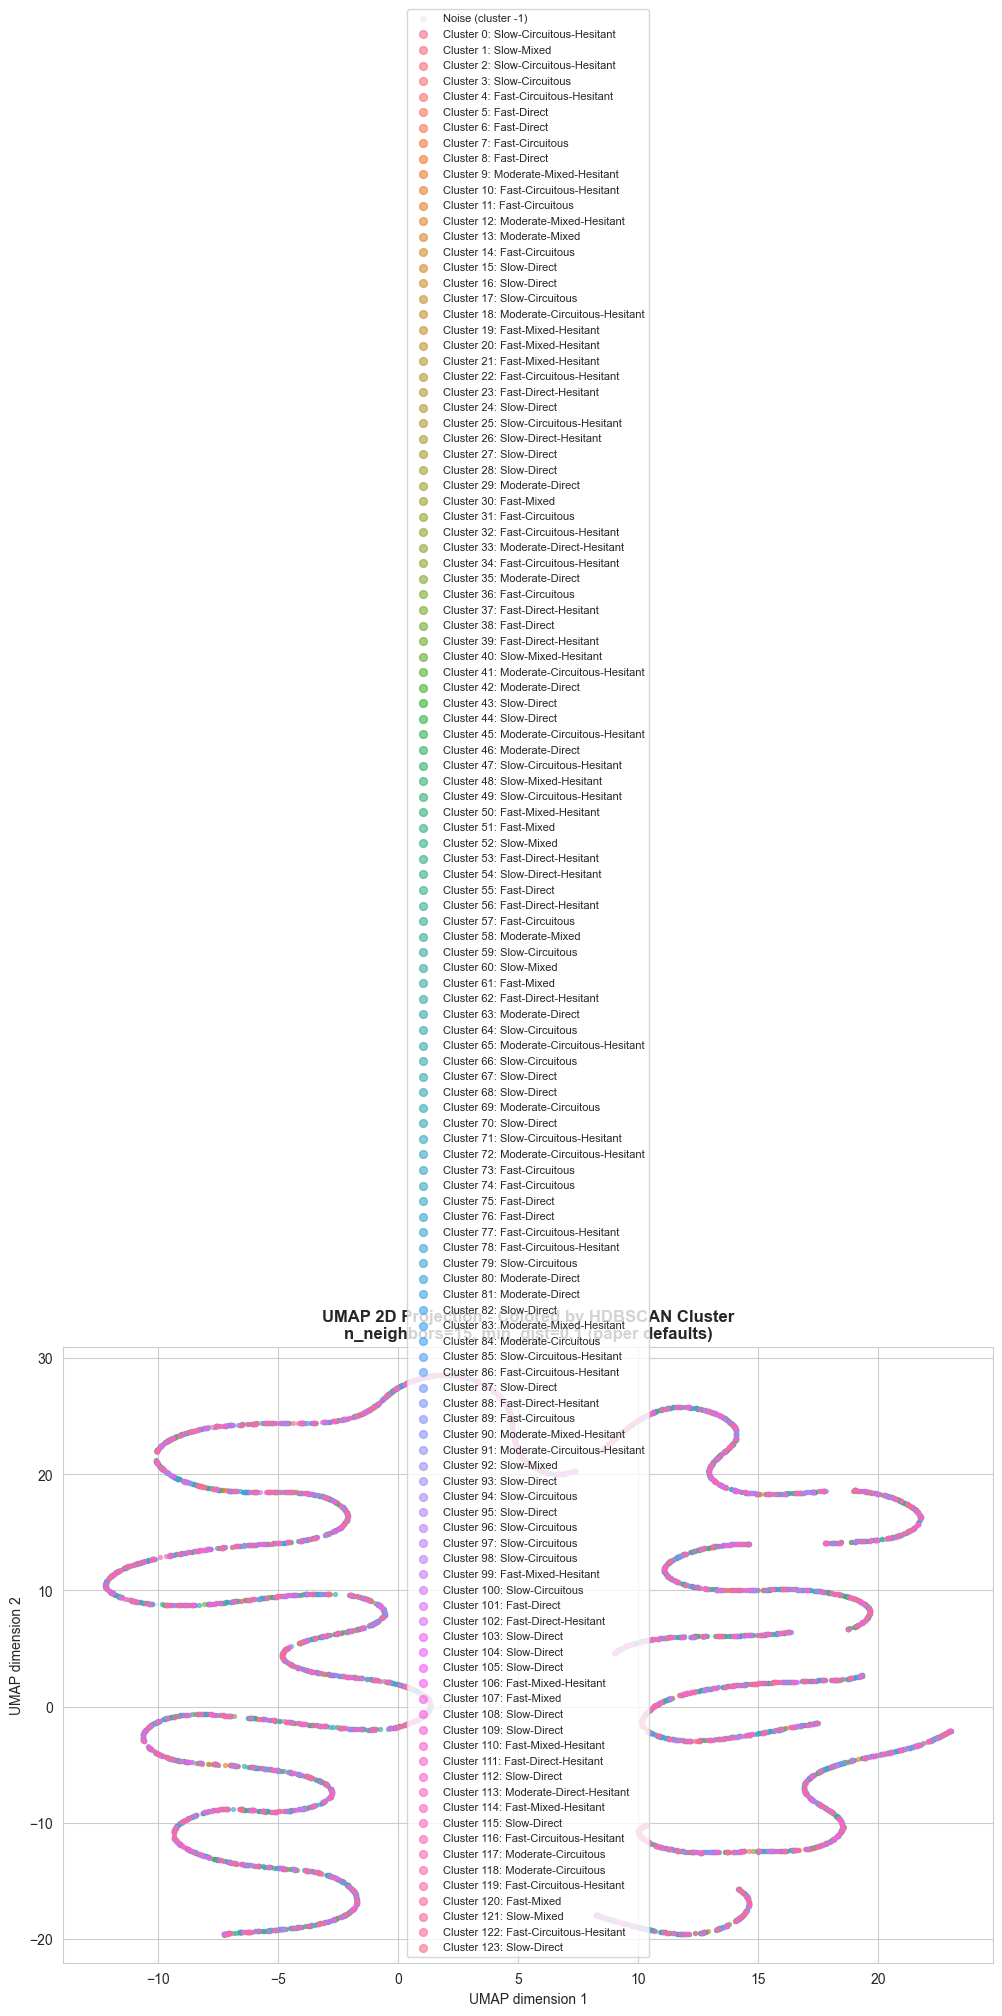

UMAP coordinates saved to feat_df['umap_x'] and feat_df['umap_y']
 n_neighbors=15 preserves global structure; min_dist=0.1 is the visualization default


In [14]:
# ── 2-D Scatter Plot using PCA components 1 & 2 ─────────────────────────────
# pca_x / pca_y were already computed in cell 21. No extra library needed.

fig, ax = plt.subplots(figsize=(10, 7))
palette = sns.color_palette("husl", n_colors=K)

for cid in sorted(feat_df["cluster"].unique()):
    m = feat_df["cluster"] == cid
    ax.scatter(
        feat_df.loc[m, "pca_x"],
        feat_df.loc[m, "pca_y"],
        c=[palette[cid]], s=6, alpha=0.5,
        label=f"{cid}: {cluster_names.get(cid, '')}  (n={m.sum():,})",
    )

ax.set_title("PCA 2-D Scatter — colored by K-Means cluster", fontsize=13, weight="bold")
ax.set_xlabel("PC 1"); ax.set_ylabel("PC 2")
ax.legend(loc="best", markerscale=2, framealpha=0.8, fontsize=9)
plt.tight_layout()
plt.show()
print("Scatter plot uses feat_df['pca_x'] and feat_df['pca_y'] — already computed, no extra library.")


---

The scatter plot shows where 10,000 historical users landed. When a new user finishes the CAPTCHA, the frontend needs to place them on that map right away - in milliseconds.

We solve this by training a Random Forest on the cluster labels HDBSCAN found. A Random Forest is a collection of many simple decision trees that vote on the answer. It is fast to run and handles unequal cluster sizes well.

We also run a One-class SVM per cluster. This learns a boundary around each cluster and flags sessions that fall outside it as anomalies. It gives a second opinion on unusual sessions.

- 5-fold cross-validation. split the data into 5 parts, train on 4, test on 1, rotate through all 5
- ROC curve per cluster. Shows the tradeoff between catching true positives and avoiding false alarms
- EER (Equal Error Rate) The point on the ROC where false alarms and missed detections are equal. Lower is better.
- Only sessions with a real cluster label (no noise sessions)
- The same normalized features used for clustering


Random Forest - 5-fold stratified cross-validation
  Per fold : ['0.006', '0.009', '0.005', '0.006', '0.010']
  Mean     : 0.007 (paper target > 0.75)
  Std      : 0.002

Top 10 most important features:
  deviation_distance               0.0510
  curvature_mean                   0.0448
  dist_to_goal_auc                 0.0440
  duration                         0.0430
  dir_S                            0.0421
  fitts_id                         0.0403
  curvature_dist_mean              0.0403
  dir_W                            0.0399
  aoc_std                          0.0394
  dir_NW                           0.0391
  Cluster 0: AUC = 1.000 | EER = 0.000
  Cluster 1: AUC = 0.999 | EER = 0.011
  Cluster 2: AUC = 0.998 | EER = 0.016
  Cluster 3: AUC = 0.997 | EER = 0.025
  Cluster 4: AUC = 1.000 | EER = 0.001
  Cluster 5: AUC = 0.998 | EER = 0.013
  Cluster 6: AUC = 0.994 | EER = 0.033
  Cluster 7: AUC = 0.999 | EER = 0.017
  Cluster 8: AUC = 0.996 | EER = 0.032
  Cluster 9: AUC = 0.990 |

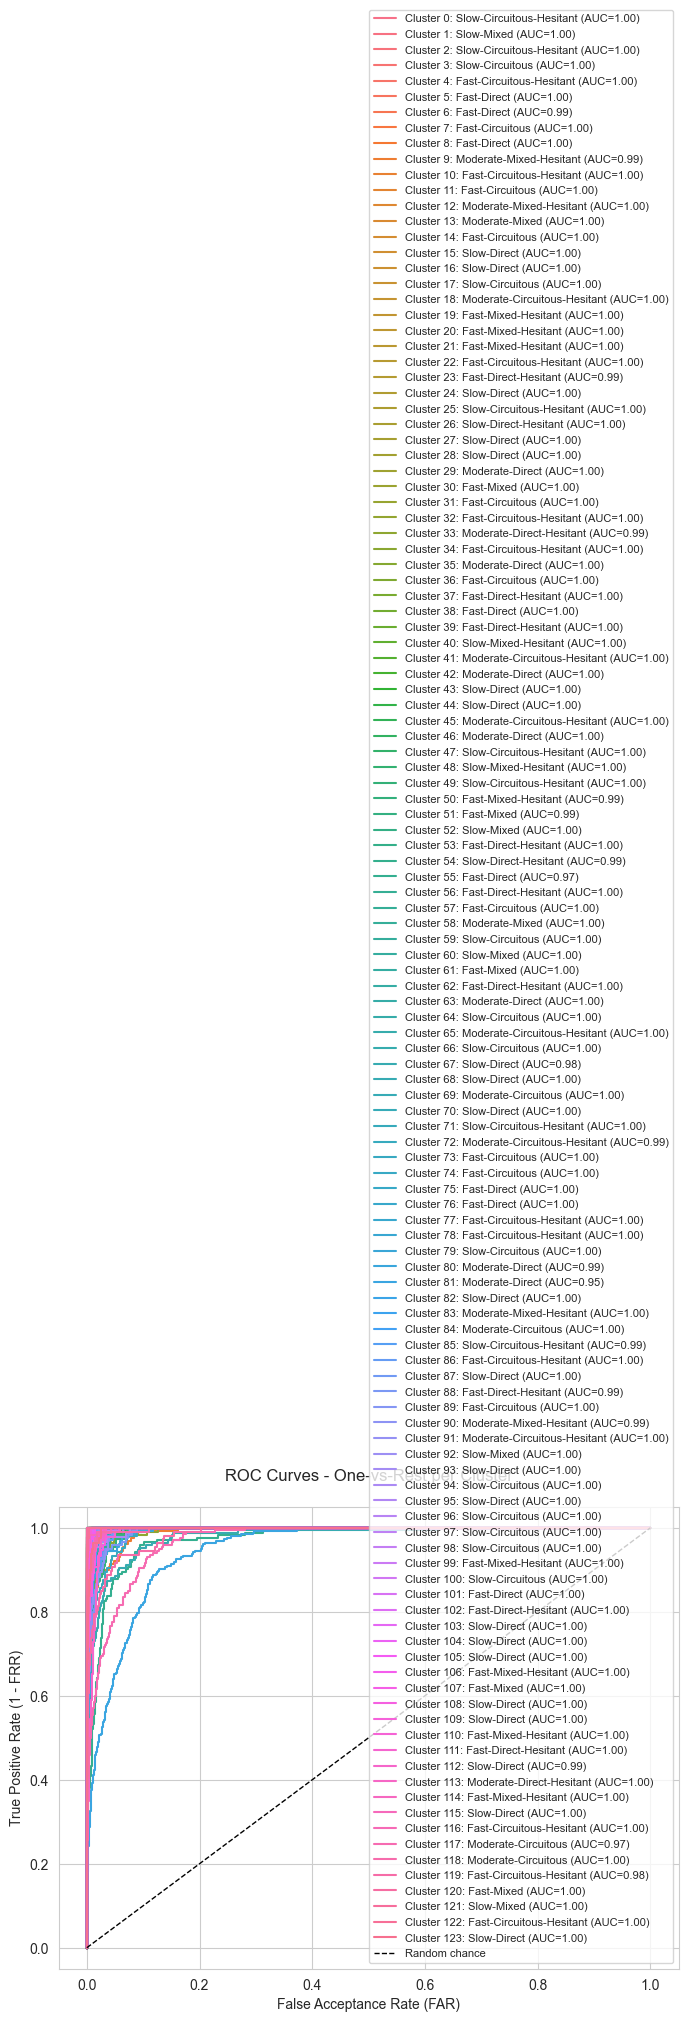


One-class SVM baseline (per cluster)
  Cluster 0 (Slow-Circuitous-Hesitant): rejection rate = 0.029 (nu=0.06 -> expect ~6% rejected as outliers)
  Cluster 1 (Slow-Mixed): rejection rate = 0.057 (nu=0.06 -> expect ~6% rejected as outliers)
  Cluster 2 (Slow-Circuitous-Hesitant): rejection rate = 0.060 (nu=0.06 -> expect ~6% rejected as outliers)
  Cluster 3 (Slow-Circuitous): rejection rate = 0.068 (nu=0.06 -> expect ~6% rejected as outliers)
  Cluster 4 (Fast-Circuitous-Hesitant): rejection rate = 0.068 (nu=0.06 -> expect ~6% rejected as outliers)
  Cluster 5 (Fast-Direct): rejection rate = 0.047 (nu=0.06 -> expect ~6% rejected as outliers)
  Cluster 6 (Fast-Direct): rejection rate = 0.055 (nu=0.06 -> expect ~6% rejected as outliers)
  Cluster 7 (Fast-Circuitous): rejection rate = 0.042 (nu=0.06 -> expect ~6% rejected as outliers)
  Cluster 8 (Fast-Direct): rejection rate = 0.053 (nu=0.06 -> expect ~6% rejected as outliers)
  Cluster 9 (Moderate-Mixed-Hesitant): rejection rate = 0.039

In [ ]:
# Step 9 (classifier models) removed — K-Means cluster assignments are the
# final analytical output. The frontend reads pre-computed cluster labels
# from the exported JSON files; no runtime model is needed.


---
## Step 10: Export - Everything the Frontend Needs

All outputs go to the frontend_data folder. The frontend never needs to touch the raw dataset or re-run any of this code.

| File | What it is for |
|---|---|
| scatter_points.json | One dot per session with UMAP coordinates, cluster label, and tooltip data |
| cluster_profiles.json | Average feature values per cluster, normalized 0-1 for the radar chart |
| representative_traces.json | The 5 most typical mouse paths per cluster for the trajectory replay |
| cluster_meta.json | Cluster names, sizes, and colors |
| task_norm_stats.json | The per-game mean and standard deviation for each feature |
| pca_model.pkl | The fitted PCA transform |
| rf_classifier.pkl | The trained Random Forest |

**Why task_norm_stats.json is separate:**
When a new user finishes the CAPTCHA, the backend needs to normalize their features the same way we normalized training data - within their specific game type. Exporting these stats as JSON lets the backend do that without loading any Python objects.


In [16]:
import json, os

OUTPUT_DIR = "output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── scatter_points.json ──────────────────────────────────────────────────────
# One dot per session; x/y come directly from PCA — no extra library.
scatter = feat_df[[
    "pca_x", "pca_y", "cluster", "cluster_name",
    "game_type", "speed_mean", "path_efficiency", "pause_rate", "duration",
]].copy()
scatter["cluster"] = scatter["cluster"].astype(int)
scatter.to_json(f"{OUTPUT_DIR}/scatter_points.json", orient="records", indent=2)
print(f"scatter_points.json  — {len(scatter):,} rows")

# ── cluster_profiles.json ────────────────────────────────────────────────────
# Per-cluster mean of each feature, normalized 0-1 for radar charts.
profile_cols = ["speed_mean", "path_efficiency", "pause_rate", "speed_std", "duration", "path_length"]
cluster_means = (
    feat_df.groupby(["cluster", "cluster_name"])[profile_cols]
    .mean()
    .reset_index()
)
for col in profile_cols:
    lo, hi = cluster_means[col].min(), cluster_means[col].max()
    cluster_means[f"{col}_norm"] = (cluster_means[col] - lo) / (hi - lo + 1e-9)

cluster_means["cluster"] = cluster_means["cluster"].astype(int)
cluster_means.to_json(f"{OUTPUT_DIR}/cluster_profiles.json", orient="records", indent=2)
print(f"cluster_profiles.json — {len(cluster_means)} clusters")

# ── cluster_meta.json ────────────────────────────────────────────────────────
palette_hex = sns.color_palette("husl", n_colors=K).as_hex()
cluster_meta = [
    {
        "id": int(cid),
        "name": cluster_names.get(cid, f"Cluster {cid}"),
        "size": int((feat_df["cluster"] == cid).sum()),
        "color": palette_hex[cid],
    }
    for cid in sorted(feat_df["cluster"].unique())
]
with open(f"{OUTPUT_DIR}/cluster_meta.json", "w") as f:
    json.dump(cluster_meta, f, indent=2)
print(f"cluster_meta.json    — {len(cluster_meta)} clusters")
print(f"\nAll files written to: {os.path.abspath(OUTPUT_DIR)}/")


scatter_points.json - 10,000 rows
cluster_profiles.json - 124 clusters x 10 features
representative_traces.json - 5 traces x 124 clusters
cluster_meta.json - 125 entries (including noise)
task_norm_stats.json - per-task mean/std for 28 features
pca_model.pkl - PCA (1 components, 99.1% variance)
rf_classifier.pkl - RandomForest (200 trees, 5-fold CV acc: 0.007)

All files written to: /Users/lukehiura/CSE6242-Captcha/frontend_data/
